In [29]:
# ==============================================================
# CELL 1 — Install required libraries
# Run once per Colab session. Restart runtime if prompted.
# ==============================================================

!pip install linearmodels rasterio rasterstats geopandas --quiet


In [30]:
# ==============================================================
# CELL 2 — Import libraries
# ==============================================================

import os
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.merge import merge as rasterio_merge
from rasterio.warp import reproject, Resampling, calculate_default_transform
from rasterio.transform import from_bounds
import rasterio.mask
from rasterstats import zonal_stats
import statsmodels.api as sm
from linearmodels.iv import IV2SLS
import matplotlib.pyplot as plt
import tempfile

warnings.filterwarnings('ignore')
print("All libraries loaded successfully.")


All libraries loaded successfully.


In [31]:
# ==============================================================
# CELL 3 — Mount Google Drive
# ==============================================================

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
# ==============================================================
# CELL 4 — Define file paths
#
# All hazard data are under:
#   MyDrive/WB_Study/Future_housing_needs/data_raw/
# ==============================================================

BASE_RAW = "/content/drive/MyDrive/WB_Study/Future_housing_needs/data_raw"

# ── Earthquake: GEM Global Seismic Hazard Map v2023.1 ──
GEM_PATH = os.path.join(
    BASE_RAW, "GEM",
    "GEM-GSHM_PGA-475y-rock_v2023",
    "v2023_1_pga_475_rock_3min.tif"
)

# ── Flood: WRI Aqueduct (100-year return period) ──
# Coastal inundation (no subsidence, historical)
FLOOD_COASTAL_PATH = os.path.join(
    BASE_RAW, "Aqueduct",
    "inuncoast_historical_nosub_hist_rp0100_0.tif"
)
# River (fluvial) inundation (WATCH baseline, 1980)
FLOOD_RIVER_PATH = os.path.join(
    BASE_RAW, "Aqueduct",
    "inunriver_historical_000000000WATCH_1980_rp00100.tif"
)

# ── Storm: STORM tropical cyclone wind speed (100-year return period) ──
# Six ocean basin files — will be mosaicked in Cell 7
STORM_DIR = os.path.join(BASE_RAW, "STORM")
STORM_FILES = [
    os.path.join(STORM_DIR, f)
    for f in [
        "STORM_FIXED_RETURN_PERIODS_EP_100_YR_RP.tif",  # East Pacific
        "STORM_FIXED_RETURN_PERIODS_NA_100_YR_RP.tif",  # North Atlantic
        "STORM_FIXED_RETURN_PERIODS_NI_100_YR_RP.tif",  # North Indian
        "STORM_FIXED_RETURN_PERIODS_SI_100_YR_RP.tif",  # South Indian
        "STORM_FIXED_RETURN_PERIODS_SP_100_YR_RP.tif",  # South Pacific
        "STORM_FIXED_RETURN_PERIODS_WP_100_YR_RP.tif",  # West Pacific
    ]
]

# ── World Bank Official Boundaries (Admin 0) ──
BOUNDARY_PATH = os.path.join(
    "/content/drive/MyDrive/WB_Study/Future_housing_needs/data_raw",
    "WB_Official_Boundaries",
    "World Bank Official Boundaries - Admin 0.gpkg"
)

# ── Main analytical dataset ──
DATA_PATH = (
    "/content/drive/MyDrive/Resilient_Housing_Global_Regression/"
    "data_processed/global_analysis_final_for_modeling.csv"
)

# ── Output directory ──
OUTPUT_DIR = (
    "/content/drive/MyDrive/Resilient_Housing_Global_Regression/Results/IV"
)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verify all files exist
all_paths = (
    [GEM_PATH, FLOOD_COASTAL_PATH, FLOOD_RIVER_PATH,
     BOUNDARY_PATH, DATA_PATH]
    + STORM_FILES
)
for p in all_paths:
    status = "OK" if os.path.exists(p) else "NOT FOUND"
    print(f"  [{status}] {os.path.basename(p)}")


  [OK] v2023_1_pga_475_rock_3min.tif
  [OK] inuncoast_historical_nosub_hist_rp0100_0.tif
  [OK] inunriver_historical_000000000WATCH_1980_rp00100.tif
  [OK] World Bank Official Boundaries - Admin 0.gpkg
  [OK] global_analysis_final_for_modeling.csv
  [OK] STORM_FIXED_RETURN_PERIODS_EP_100_YR_RP.tif
  [OK] STORM_FIXED_RETURN_PERIODS_NA_100_YR_RP.tif
  [OK] STORM_FIXED_RETURN_PERIODS_NI_100_YR_RP.tif
  [OK] STORM_FIXED_RETURN_PERIODS_SI_100_YR_RP.tif
  [OK] STORM_FIXED_RETURN_PERIODS_SP_100_YR_RP.tif
  [OK] STORM_FIXED_RETURN_PERIODS_WP_100_YR_RP.tif


In [33]:
# ==============================================================
# CELL 5 — Load and inspect boundary file
#
# Confirmed columns: WB_A3, NAM_0, WB_REGION
# Confirmed CRS: EPSG:4326
# ==============================================================

boundaries = gpd.read_file(BOUNDARY_PATH)
print(f"Boundary CRS : {boundaries.crs}")
print(f"Rows         : {len(boundaries)}")
print(f"Columns      : {list(boundaries.columns)}")


Boundary CRS : EPSG:4326
Rows         : 264
Columns      : ['ISO_A3', 'ISO_A2', 'WB_A3', 'HASC_0', 'GAUL_0', 'WB_REGION', 'WB_STATUS', 'SOVEREIGN', 'NAM_0', 'geometry']


In [34]:
# ==============================================================
# CELL 6 — Zonal statistics: GEM earthquake hazard (PGA)
#
# Extracts mean PGA per country polygon.
# Runtime: approximately 2-5 minutes.
# ==============================================================

print("Processing GEM seismic hazard ...")

with rasterio.open(GEM_PATH) as src:
    gem_crs    = src.crs
    gem_nodata = src.nodata

bounds_gem = boundaries.copy()
if boundaries.crs != gem_crs:
    bounds_gem = boundaries.to_crs(gem_crs)

stats_gem = zonal_stats(
    vectors     = bounds_gem,
    raster      = GEM_PATH,
    stats       = ['mean', 'median', 'max'],
    nodata      = gem_nodata,
    all_touched = False,
    geojson_out = False
)

boundaries['GEM_PGA_mean']   = [s['mean']   for s in stats_gem]
boundaries['GEM_PGA_median'] = [s['median'] for s in stats_gem]

print(f"GEM done. Non-null countries: "
      f"{sum(1 for s in stats_gem if s['mean'] is not None)}")


Processing GEM seismic hazard ...
GEM done. Non-null countries: 222


In [35]:
# ==============================================================
# CELL 7 — Zonal statistics: Flood hazard (Aqueduct)
#
# APPROACH: Take the cell-wise maximum of coastal and river
# inundation depth before computing country-level statistics.
#
# Rationale: A country faces flood risk from either coastal or
# river sources. Using the maximum captures the worst-case
# inundation relevant to housing robustness decisions, and
# avoids double-counting when both rasters cover the same area.
#
# IMPLEMENTATION:
#   Step 1 — Reproject river raster to match coastal CRS/resolution
#             (coastal is used as the reference grid, as it tends
#             to have finer resolution in Aqueduct).
#   Step 2 — Compute cell-wise max, masking nodata cells.
#   Step 3 — Write combined raster to a temporary file.
#   Step 4 — Run zonal statistics on combined raster.
#
# Runtime: approximately 5-10 minutes depending on raster size.
# ==============================================================

print("Processing Aqueduct flood hazard ...")

FLOOD_COMBINED_PATH = os.path.join(OUTPUT_DIR, "flood_max_combined.tif")

with rasterio.open(FLOOD_COASTAL_PATH) as coast_src:
    coast_data   = coast_src.read(1).astype(np.float32)
    coast_nodata = coast_src.nodata if coast_src.nodata else -9999
    coast_meta   = coast_src.meta.copy()
    coast_crs    = coast_src.crs
    coast_transform = coast_src.transform
    coast_shape  = coast_src.shape

    # Replace nodata with 0 for max comparison
    coast_arr = np.where(coast_data == coast_nodata, 0, coast_data)
    coast_arr = np.maximum(coast_arr, 0)  # clip negatives

    # Reproject river raster to coastal grid
    with rasterio.open(FLOOD_RIVER_PATH) as river_src:
        river_repr = np.zeros(coast_shape, dtype=np.float32)
        reproject(
            source          = rasterio.band(river_src, 1),
            destination     = river_repr,
            src_transform   = river_src.transform,
            src_crs         = river_src.crs,
            dst_transform   = coast_transform,
            dst_crs         = coast_crs,
            resampling      = Resampling.bilinear,
            src_nodata      = river_src.nodata,
            dst_nodata      = 0
        )
    river_arr = np.maximum(river_repr, 0)

    # Cell-wise maximum
    flood_max = np.maximum(coast_arr, river_arr)

    # Write combined raster
    out_meta = coast_meta.copy()
    out_meta.update({'dtype': 'float32', 'nodata': -9999})
    with rasterio.open(FLOOD_COMBINED_PATH, 'w', **out_meta) as dst:
        dst.write(flood_max, 1)

print(f"  Combined flood raster saved: {FLOOD_COMBINED_PATH}")

# Zonal statistics
bounds_flood = boundaries.copy()
if boundaries.crs != coast_crs:
    bounds_flood = boundaries.to_crs(coast_crs)

stats_flood = zonal_stats(
    vectors     = bounds_flood,
    raster      = FLOOD_COMBINED_PATH,
    stats       = ['mean', 'median', 'max'],
    nodata      = -9999,
    all_touched = False,
    geojson_out = False
)

boundaries['FLOOD_mean']   = [s['mean']   for s in stats_flood]
boundaries['FLOOD_median'] = [s['median'] for s in stats_flood]

print(f"Flood done. Non-null countries: "
      f"{sum(1 for s in stats_flood if s['mean'] is not None)}")


Processing Aqueduct flood hazard ...
  Combined flood raster saved: /content/drive/MyDrive/Resilient_Housing_Global_Regression/Results/IV/flood_max_combined.tif
Flood done. Non-null countries: 260


In [36]:
# ==============================================================
# CELL 8 — Zonal statistics: Storm hazard (STORM)
#
# APPROACH: Mosaic 6 regional wind speed rasters into a single
# global raster, then compute country-level statistics.
#
# Rationale: STORM provides separate files by ocean basin.
# In overlapping regions (if any), rasterio.merge uses the
# 'max' method to take the highest wind speed — appropriate
# for capturing the worst-case tropical cyclone risk.
#
# Countries outside tropical cyclone tracks will have zero or
# nodata values, which are treated as zero wind speed exposure.
#
# Runtime: approximately 5-10 minutes.
# ==============================================================

print("Processing STORM tropical cyclone wind speed ...")

STORM_GLOBAL_PATH = os.path.join(OUTPUT_DIR, "storm_wind_global.tif")

# Open all regional files
storm_datasets = [rasterio.open(f) for f in STORM_FILES]

# Mosaic with max method (handles overlapping regions correctly)
storm_mosaic, storm_transform = rasterio_merge(
    storm_datasets, method='max'
)

# Use metadata from first file as template
storm_meta = storm_datasets[0].meta.copy()
storm_meta.update({
    'height'   : storm_mosaic.shape[1],
    'width'    : storm_mosaic.shape[2],
    'transform': storm_transform,
    'dtype'    : 'float32',
    'nodata'   : storm_datasets[0].nodata,
})

# Close all datasets
for ds in storm_datasets:
    ds.close()

# Write global mosaic
storm_arr = storm_mosaic[0].astype(np.float32)
with rasterio.open(STORM_GLOBAL_PATH, 'w', **storm_meta) as dst:
    dst.write(storm_arr, 1)

print(f"  Global storm raster saved: {STORM_GLOBAL_PATH}")

# Zonal statistics
storm_crs    = storm_meta['crs']
storm_nodata = storm_meta['nodata']

bounds_storm = boundaries.copy()
if boundaries.crs != storm_crs:
    bounds_storm = boundaries.to_crs(storm_crs)

stats_storm = zonal_stats(
    vectors     = bounds_storm,
    raster      = STORM_GLOBAL_PATH,
    stats       = ['mean', 'median', 'max'],
    nodata      = storm_nodata,
    all_touched = False,
    geojson_out = False
)

boundaries['STORM_mean']   = [s['mean']   for s in stats_storm]
boundaries['STORM_median'] = [s['median'] for s in stats_storm]

# Countries with no cyclone exposure get 0 (not NaN)
boundaries['STORM_mean']   = boundaries['STORM_mean'].fillna(0)
boundaries['STORM_median'] = boundaries['STORM_median'].fillna(0)

print(f"Storm done. Countries with cyclone exposure (mean > 0): "
      f"{(boundaries['STORM_mean'] > 0).sum()}")


Processing STORM tropical cyclone wind speed ...
  Global storm raster saved: /content/drive/MyDrive/Resilient_Housing_Global_Regression/Results/IV/storm_wind_global.tif
Storm done. Countries with cyclone exposure (mean > 0): 103


In [37]:
# ==============================================================
# CELL 8 — Zonal statistics: Storm hazard (STORM)
#
# APPROACH: Mosaic 6 regional wind speed rasters into a single
# global raster, then compute country-level statistics.
#
# Rationale: STORM provides separate files by ocean basin.
# In overlapping regions (if any), rasterio.merge uses the
# 'max' method to take the highest wind speed — appropriate
# for capturing the worst-case tropical cyclone risk.
#
# Countries outside tropical cyclone tracks will have zero or
# nodata values, which are treated as zero wind speed exposure.
#
# Runtime: approximately 5-10 minutes.
# ==============================================================

print("Processing STORM tropical cyclone wind speed ...")

STORM_GLOBAL_PATH = os.path.join(OUTPUT_DIR, "storm_wind_global.tif")

# Open all regional files
storm_datasets = [rasterio.open(f) for f in STORM_FILES]

# Mosaic with max method (handles overlapping regions correctly)
storm_mosaic, storm_transform = rasterio_merge(
    storm_datasets, method='max'
)

# Use metadata from first file as template
storm_meta = storm_datasets[0].meta.copy()
storm_meta.update({
    'height'   : storm_mosaic.shape[1],
    'width'    : storm_mosaic.shape[2],
    'transform': storm_transform,
    'dtype'    : 'float32',
    'nodata'   : storm_datasets[0].nodata,
})

# Close all datasets
for ds in storm_datasets:
    ds.close()

# Write global mosaic
storm_arr = storm_mosaic[0].astype(np.float32)
with rasterio.open(STORM_GLOBAL_PATH, 'w', **storm_meta) as dst:
    dst.write(storm_arr, 1)

print(f"  Global storm raster saved: {STORM_GLOBAL_PATH}")

# Zonal statistics
storm_crs    = storm_meta['crs']
storm_nodata = storm_meta['nodata']

bounds_storm = boundaries.copy()
if boundaries.crs != storm_crs:
    bounds_storm = boundaries.to_crs(storm_crs)

stats_storm = zonal_stats(
    vectors     = bounds_storm,
    raster      = STORM_GLOBAL_PATH,
    stats       = ['mean', 'median', 'max'],
    nodata      = storm_nodata,
    all_touched = False,
    geojson_out = False
)

boundaries['STORM_mean']   = [s['mean']   for s in stats_storm]
boundaries['STORM_median'] = [s['median'] for s in stats_storm]

# Countries with no cyclone exposure get 0 (not NaN)
boundaries['STORM_mean']   = boundaries['STORM_mean'].fillna(0)
boundaries['STORM_median'] = boundaries['STORM_median'].fillna(0)

print(f"Storm done. Countries with cyclone exposure (mean > 0): "
      f"{(boundaries['STORM_mean'] > 0).sum()}")


Processing STORM tropical cyclone wind speed ...
  Global storm raster saved: /content/drive/MyDrive/Resilient_Housing_Global_Regression/Results/IV/storm_wind_global.tif
Storm done. Countries with cyclone exposure (mean > 0): 103


In [38]:
# ==============================================================
# CELL 9 — Save country-level hazard values to CSV
#
# Saves all three hazard instruments to a single CSV.
# This file can be reloaded to skip Cells 6-8 on subsequent runs.
# ==============================================================

pga_country = boundaries[[
    'WB_A3', 'NAM_0',
    'GEM_PGA_mean',  'GEM_PGA_median',
    'FLOOD_mean',    'FLOOD_median',
    'STORM_mean',    'STORM_median',
]].copy()

HAZARD_CACHE = os.path.join(OUTPUT_DIR, "hazard_instruments_by_country.csv")
pga_country.to_csv(HAZARD_CACHE, index=False)
print(f"Saved: {HAZARD_CACHE}")

# To reload on subsequent runs (skip Cells 6-8):
# pga_country = pd.read_csv(HAZARD_CACHE)

print("\nHazard value summary:")
print(pga_country[['GEM_PGA_mean', 'FLOOD_mean', 'STORM_mean']].describe().round(4))


Saved: /content/drive/MyDrive/Resilient_Housing_Global_Regression/Results/IV/hazard_instruments_by_country.csv

Hazard value summary:
       GEM_PGA_mean  FLOOD_mean  STORM_mean
count      222.0000    260.0000    264.0000
mean         0.1414      0.0688     10.3059
std          0.1662      0.3986     16.4732
min          0.0000      0.0000      0.0000
25%          0.0194      0.0043      0.0000
50%          0.0782      0.0235      0.0000
75%          0.2490      0.0523     20.4807
max          1.1923      6.3062     48.8759


In [39]:
# ==============================================================
# CELL 10 — Deduplicate boundary file by WB_A3
#
# The WB boundary file contains 222 polygons but only 208 unique
# WB_A3 codes. Aggregate by WB_A3 using mean across polygons
# before merging with main dataset.
# ==============================================================

pga_dedup = (
    pga_country
    .groupby('WB_A3', as_index=False)
    .agg({
        'NAM_0'          : 'first',
        'GEM_PGA_mean'   : 'mean',
        'GEM_PGA_median' : 'mean',
        'FLOOD_mean'     : 'mean',
        'FLOOD_median'   : 'mean',
        'STORM_mean'     : 'mean',
        'STORM_median'   : 'mean',
    })
)
print(f"After dedup: {len(pga_dedup)} unique WB_A3 codes "
      f"(was {len(pga_country)} polygons)")

pga_by_name = pga_dedup.set_index('NAM_0')


After dedup: 235 unique WB_A3 codes (was 264 polygons)


In [40]:
# ==============================================================
# CELL 11 — Load main dataset and merge hazard values (two steps)
#
# Step A: ISO code match  (ISO_CODE in CSV vs WB_A3 in boundary)
# Step B: Country name match (COUNTRY_NAME vs NAM_0)
# ==============================================================

df = pd.read_csv(DATA_PATH)
N_ORIGINAL = len(df)
print(f"Main dataset loaded: {N_ORIGINAL} rows x {df.shape[1]} cols")

HAZARD_COLS = ['GEM_PGA_mean', 'GEM_PGA_median',
               'FLOOD_mean', 'FLOOD_median',
               'STORM_mean', 'STORM_median']

# STEP A: ISO code merge
df = df.merge(
    pga_dedup[['WB_A3', 'NAM_0'] + HAZARD_COLS],
    left_on  = 'ISO_CODE',
    right_on = 'WB_A3',
    how      = 'left'
)
assert len(df) == N_ORIGINAL, \
    f"Row inflation after Step A: {len(df)} != {N_ORIGINAL}"

step_a = df['GEM_PGA_mean'].notna().sum()
print(f"Step A (ISO code)   — Matched: {step_a}, "
      f"Unmatched: {N_ORIGINAL - step_a}")

# STEP B: Country name direct match for remaining unmatched rows
step_b_fixed = 0
for idx in df[df['GEM_PGA_mean'].isna()].index:
    cname = df.at[idx, 'COUNTRY_NAME']
    if cname in pga_by_name.index:
        for col in HAZARD_COLS:
            df.at[idx, col] = pga_by_name.at[cname, col]
        step_b_fixed += 1

step_ab = df['GEM_PGA_mean'].notna().sum()
print(f"Step B (name match) — Fixed: {step_b_fixed}")
print(f"After Steps A+B     — Matched: {step_ab}, "
      f"Unmatched: {N_ORIGINAL - step_ab}")


Main dataset loaded: 217 rows x 133 cols
Step A (ISO code)   — Matched: 179, Unmatched: 38
Step B (name match) — Fixed: 20
After Steps A+B     — Matched: 191, Unmatched: 26


In [41]:
# ==============================================================
# CELL 12 — Manual corrections via WB_A3 lookup
#
# Three confirmed issues:
#   1. NAM_0 encoding corruption (UTF-8/Latin-1 mismatch)
#   2. NAM_0 includes parenthetical qualifiers
#   3. Countries absent from WB boundary file
#
# Fix: look up by WB_A3 code for issues 1 and 2.
# Issue 3 countries remain NaN and are excluded in Cell 13.
# ==============================================================

wb_a3_corrections = {
    "Cote d'Ivoire"         : 'CIV',
    'Curacao'               : 'CUW',
    'Sao Tome and Principe' : 'STP',
    'Turkiye'               : 'TUR',
    'Aruba'                 : 'ABW',
    'Faroe Islands'         : 'FRO',
    'Isle of Man'           : 'IMY',
    'Congo, Dem. Rep.'      : 'DRC',
}

available_wb_a3 = set(pga_dedup['WB_A3'].values)
fixed_count = 0

for csv_name, wb_a3 in wb_a3_corrections.items():
    rows_to_fix = (df['COUNTRY_NAME'] == csv_name) & df['GEM_PGA_mean'].isna()
    if rows_to_fix.sum() == 0:
        continue
    if wb_a3 not in available_wb_a3:
        print(f"  WARN: {csv_name} — WB_A3={wb_a3} not in boundary")
        continue
    match = pga_dedup.loc[pga_dedup['WB_A3'] == wb_a3]
    for col in HAZARD_COLS:
        df.loc[rows_to_fix, col] = match[col].values[0]
    print(f"  Fixed: {csv_name:<35} WB_A3={wb_a3}  "
          f"PGA={match['GEM_PGA_mean'].values[0]:.4f}  "
          f"FLD={match['FLOOD_mean'].values[0]:.4f}  "
          f"STM={match['STORM_mean'].values[0]:.4f}")
    fixed_count += 1

print(f"\nFixed {fixed_count} countries.")
print(f"Total matched  : {df['GEM_PGA_mean'].notna().sum()} / {N_ORIGINAL}")
print(f"Still unmatched: {df['GEM_PGA_mean'].isna().sum()} "
      f"(absent from WB boundary — excluded in Cell 13)")


  Fixed: Cote d'Ivoire                       WB_A3=CIV  PGA=0.0024  FLD=0.1726  STM=0.0000
  Fixed: Curacao                             WB_A3=CUW  PGA=0.0410  FLD=0.0058  STM=40.7496
  Fixed: Sao Tome and Principe               WB_A3=STP  PGA=0.0012  FLD=0.0129  STM=0.0000
  Fixed: Aruba                               WB_A3=ABW  PGA=0.1291  FLD=0.0000  STM=40.1739
  Fixed: Faroe Islands                       WB_A3=FRO  PGA=0.0000  FLD=0.0002  STM=0.0000
  Fixed: Isle of Man                         WB_A3=IMY  PGA=0.0052  FLD=0.0233  STM=25.3063
  Fixed: Congo, Dem. Rep.                    WB_A3=DRC  PGA=0.0443  FLD=0.0811  STM=0.0000

Fixed 7 countries.
Total matched  : 198 / 217
Still unmatched: 19 (absent from WB boundary — excluded in Cell 13)


In [42]:
# ==============================================================
# CELL 13 — Variable transformation and analytical sample
#
# Three hazard instruments:
#   log_GEM_PGA   : instrument for earthquake exposure (log_EQK)
#   log_FLOOD_HAZ : instrument for flood exposure (log_FLD)
#   log_STORM_HAZ : instrument for storm exposure (log_STM)
#
# log1p = log(1 + x) handles zero values safely.
# Preferred IV specification excludes BQCI (treated as mediator).
#
# dtype=int for region dummies: required for statsmodels/
# linearmodels compatibility (pd.get_dummies returns bool
# in pandas >= 1.5).
# ==============================================================

# Log transformations
df['log_GDP']       = np.log(df['WB_GDP_PCAP_PPP_INTL_2021_VALUE'])
df['log_EQK']       = np.log1p(df['DIS_EQK'])
df['log_STM']       = np.log1p(df['DIS_STM'])
df['log_FLD']       = np.log1p(df['DIS_FLD'])
df['log_GEM_PGA']   = np.log1p(df['GEM_PGA_mean'])
df['log_FLOOD_HAZ'] = np.log1p(df['FLOOD_mean'])
df['log_STORM_HAZ'] = np.log1p(df['STORM_mean'])

# Preferred controls (BQCI excluded — treated as mediator)
CONTROLS = [
    'log_GDP',
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE',
    'WB_URBAN_POPULATION_PCT_VALUE',
    'log_STM',
    'log_FLD',
    'log_EQK',
]

# Note: each IV regression will exclude the target endogenous
# variable from controls and instrument for it separately.

REQUIRED_VARS = (
    ['COUNTRY_NAME', 'REGION',
     'VULN_DEFAULT_ROBUSTNESS', 'VULN_DEFAULT_ROBUST_ONLY',
     'log_EQK', 'log_STM', 'log_FLD',
     'log_GEM_PGA', 'log_FLOOD_HAZ', 'log_STORM_HAZ']
    + ['log_GDP',
       'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE',
       'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE',
       'WB_URBAN_POPULATION_PCT_VALUE']
)
region_fill = {
    'Viet Nam': 'East Asia & Pacific',

}
for country, region in region_fill.items():
    df.loc[df['COUNTRY_NAME'] == country, 'REGION'] = region


df_iv = df[REQUIRED_VARS].dropna().copy().reset_index(drop=True)
print(f"IV analytical sample: N = {len(df_iv)} countries")

# Region fixed effects
region_dummies = pd.get_dummies(
    df_iv['REGION'], prefix='REG', drop_first=True
).astype(int)
df_iv = pd.concat([df_iv, region_dummies], axis=1)
region_cols = list(region_dummies.columns)

# Ensure float64 for all analytical columns
analytical_cols = (
    ['log_EQK', 'log_STM', 'log_FLD',
     'log_GEM_PGA', 'log_FLOOD_HAZ', 'log_STORM_HAZ',
     'log_GDP', 'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE',
     'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE',
     'WB_URBAN_POPULATION_PCT_VALUE',
     'VULN_DEFAULT_ROBUSTNESS', 'VULN_DEFAULT_ROBUST_ONLY']
    + region_cols
)
for col in analytical_cols:
    df_iv[col] = pd.to_numeric(df_iv[col], errors='coerce')

object_cols = df_iv[analytical_cols].select_dtypes('object').columns.tolist()
if object_cols:
    print(f"WARNING: Object-dtype columns: {object_cols}")
else:
    print("All analytical columns are numeric. Ready for regression.")

DEPENDENT_VARS = {
    'Non-Fragile (ROBUSTNESS)': 'VULN_DEFAULT_ROBUSTNESS',
    'Robust Only'              : 'VULN_DEFAULT_ROBUST_ONLY',
}

# Base controls (excluding all disaster exposure variables)
BASE_CONTROLS = [
    'log_GDP',
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE',
    'WB_URBAN_POPULATION_PCT_VALUE',
] + region_cols


IV analytical sample: N = 146 countries
All analytical columns are numeric. Ready for regression.


In [43]:
# ==============================================================
# CELL 14 — OLS vs IV sample comparison
# ==============================================================

df_ols_check = df.dropna(
    subset=['VULN_DEFAULT_ROBUSTNESS', 'log_EQK', 'log_STM', 'log_FLD']
            + ['log_GDP',
               'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE',
               'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE',
               'WB_URBAN_POPULATION_PCT_VALUE']
)
print(f"OLS sample (no hazard instruments required): N = {len(df_ols_check)}")
print(f"IV  sample (all hazard instruments required): N = {len(df_iv)}")

dropouts = (set(df_ols_check['COUNTRY_NAME'])
            - set(df_iv['COUNTRY_NAME']))
print(f"\nCountries in OLS but not IV (N={len(dropouts)}): {sorted(dropouts)}")


OLS sample (no hazard instruments required): N = 153
IV  sample (all hazard instruments required): N = 146

Countries in OLS but not IV (N=7): ['Haiti', 'Iraq', 'Marshall Islands', 'Mauritius', 'Micronesia, Fed. Sts.', 'Seychelles', 'Tuvalu']


In [44]:
# ==============================================================
# CELL 15 — First stage: validate all three instruments
#
# For each endogenous variable (EQK, FLD, STM), the first stage
# regresses the disaster exposure variable on its instrument
# plus the other two disaster variables as controls,
# along with the base socioeconomic controls.
#
# Partial F-statistic threshold (Stock & Yogo 2005):
#   F > 10 : relevant   F > 16 : strong
# ==============================================================

print("=" * 65)
print("FIRST STAGE RESULTS — All Three Hazard Instruments")
print("=" * 65)

# Configuration for each instrument
INSTRUMENT_CONFIG = {
    'Earthquake': {
        'endog'     : 'log_EQK',
        'instrument': 'log_GEM_PGA',
        'other_dis' : ['log_STM', 'log_FLD'],
        'iv_label'  : 'GEM PGA (475-yr)',
    },
    'Flood': {
        'endog'     : 'log_FLD',
        'instrument': 'log_FLOOD_HAZ',
        'other_dis' : ['log_EQK', 'log_STM'],
        'iv_label'  : 'Aqueduct Flood Depth (100-yr)',
    },
    'Storm': {
        'endog'     : 'log_STM',
        'instrument': 'log_STORM_HAZ',
        'other_dis' : ['log_EQK', 'log_FLD'],
        'iv_label'  : 'STORM Wind Speed (100-yr)',
    },
}

first_stage_results = {}

def compute_partial_F(y, X_full, X_restricted):
    """Compute partial F-statistic for excluded instrument."""
    n, k   = len(y), X_full.shape[1]
    r2_f   = sm.OLS(y, X_full).fit().rsquared
    r2_r   = sm.OLS(y, X_restricted).fit().rsquared
    return ((r2_f - r2_r) / 1) / ((1 - r2_f) / (n - k))

for hazard, cfg in INSTRUMENT_CONFIG.items():
    controls_fs = BASE_CONTROLS + cfg['other_dis']
    X_full = sm.add_constant(
        df_iv[[cfg['instrument']] + controls_fs]
    )
    X_rest = sm.add_constant(df_iv[controls_fs])
    y      = df_iv[cfg['endog']]

    fs_model  = sm.OLS(y, X_full).fit(cov_type='HC1')
    partial_F = compute_partial_F(y, X_full, X_rest)

    first_stage_results[hazard] = {
        'model'    : fs_model,
        'partial_F': partial_F,
        'r2'       : fs_model.rsquared,
        'coef'     : fs_model.params[cfg['instrument']],
        'pval'     : fs_model.pvalues[cfg['instrument']],
    }

    strength = ("Strong (F>=16)" if partial_F >= 16
                else "Acceptable (F>=10)" if partial_F >= 10
                else "WEAK (F<10)")
    print(f"\n{hazard} — Instrument: {cfg['iv_label']}")
    print(f"  Instrument coef = {fs_model.params[cfg['instrument']]:.4f}  "
          f"p = {fs_model.pvalues[cfg['instrument']]:.6f}")
    print(f"  Partial F       = {partial_F:.2f}  [{strength}]")
    print(f"  First-stage R2  = {fs_model.rsquared:.3f}")


FIRST STAGE RESULTS — All Three Hazard Instruments

Earthquake — Instrument: GEM PGA (475-yr)
  Instrument coef = 2.9411  p = 0.000000
  Partial F       = 31.08  [Strong (F>=16)]
  First-stage R2  = 0.556

Flood — Instrument: Aqueduct Flood Depth (100-yr)
  Instrument coef = 0.6021  p = 0.708504
  Partial F       = 0.23  [WEAK (F<10)]
  First-stage R2  = 0.486

Storm — Instrument: STORM Wind Speed (100-yr)
  Instrument coef = 0.4499  p = 0.000000
  Partial F       = 55.98  [Strong (F>=16)]
  First-stage R2  = 0.603


In [45]:
# ==============================================================
# CELL 16 — Second stage: 2SLS for each hazard type
#
# For each endogenous variable, the second stage includes:
#   - Exogenous: base controls + other two disaster variables
#   - Endogenous: target disaster variable
#   - Instrument: corresponding hazard index
#
# Wu-Hausman test reported for each specification.
# ==============================================================

iv_results_all = {}

for hazard, cfg in INSTRUMENT_CONFIG.items():
    controls_ss = BASE_CONTROLS + cfg['other_dis']
    exog        = sm.add_constant(df_iv[controls_ss])
    endog       = df_iv[[cfg['endog']]]
    instruments = df_iv[[cfg['instrument']]]

    print("\n" + "=" * 65)
    print(f"IV (2SLS) — Instrument for {hazard} Exposure")
    print(f"Instrument: {cfg['iv_label']}")
    print("=" * 65)

    iv_results_all[hazard] = {}

    for dv_label, dv_col in DEPENDENT_VARS.items():
        iv_model = IV2SLS(
            dependent   = df_iv[dv_col],
            exog        = exog,
            endog       = endog,
            instruments = instruments
        ).fit(cov_type='robust')

        iv_results_all[hazard][dv_label] = iv_model

        coef = iv_model.params[cfg['endog']]
        se   = iv_model.std_errors[cfg['endog']]
        pval = iv_model.pvalues[cfg['endog']]
        wh   = iv_model.wu_hausman()

        def stars(p):
            return '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''

        print(f"\n  Outcome: {dv_label}")
        print(f"    IV coef = {coef:.4f}{stars(pval)}  "
              f"SE = {se:.4f}  p = {pval:.4f}")
        print(f"    Wu-Hausman: stat={wh.stat:.4f}  p={wh.pval:.4f}  "
              f"({'IV justified' if wh.pval<0.05 else 'OLS consistent'})")



IV (2SLS) — Instrument for Earthquake Exposure
Instrument: GEM PGA (475-yr)

  Outcome: Non-Fragile (ROBUSTNESS)
    IV coef = 0.1693***  SE = 0.0508  p = 0.0009
    Wu-Hausman: stat=5.4578  p=0.0210  (IV justified)

  Outcome: Robust Only
    IV coef = 0.0335  SE = 0.0358  p = 0.3498
    Wu-Hausman: stat=0.1025  p=0.7494  (OLS consistent)

IV (2SLS) — Instrument for Flood Exposure
Instrument: Aqueduct Flood Depth (100-yr)

  Outcome: Non-Fragile (ROBUSTNESS)
    IV coef = -0.7119  SE = 1.9431  p = 0.7141
    Wu-Hausman: stat=3.1066  p=0.0803  (OLS consistent)

  Outcome: Robust Only
    IV coef = -0.2983  SE = 0.8963  p = 0.7393
    Wu-Hausman: stat=0.6304  p=0.4286  (OLS consistent)

IV (2SLS) — Instrument for Storm Exposure
Instrument: STORM Wind Speed (100-yr)

  Outcome: Non-Fragile (ROBUSTNESS)
    IV coef = 0.0282  SE = 0.0284  p = 0.3206
    Wu-Hausman: stat=0.7314  p=0.3940  (OLS consistent)

  Outcome: Robust Only
    IV coef = -0.0244  SE = 0.0248  p = 0.3249
    Wu-Hausman

In [46]:
# ==============================================================
# CELL 17 — OLS vs IV comparison table (all three hazards)
# ==============================================================

print("=" * 80)
print("COMPARISON: OLS vs IV — Coefficient on Disaster Exposure Variable")
print("=" * 80)
print(f"{'Hazard':<12} {'Outcome':<28} "
      f"{'OLS Coef':>9} {'OLS SE':>7} {'IV Coef':>9} {'IV SE':>7} {'WH p':>7}")
print("-" * 80)

comparison_rows = []

for hazard, cfg in INSTRUMENT_CONFIG.items():
    controls_ols = BASE_CONTROLS + cfg['other_dis']
    X_ols = sm.add_constant(df_iv[[cfg['endog']] + controls_ols])

    for dv_label, dv_col in DEPENDENT_VARS.items():
        ols  = sm.OLS(df_iv[dv_col], X_ols).fit(cov_type='HC1')
        iv   = iv_results_all[hazard][dv_label]
        wh   = iv.wu_hausman()

        ols_c = ols.params[cfg['endog']]
        ols_s = ols.bse[cfg['endog']]
        iv_c  = iv.params[cfg['endog']]
        iv_s  = iv.std_errors[cfg['endog']]

        print(f"{hazard:<12} {dv_label:<28} "
              f"{ols_c:>9.4f} {ols_s:>7.4f} "
              f"{iv_c:>9.4f} {iv_s:>7.4f} {wh.pval:>7.4f}")

        comparison_rows.append({
            'Hazard'   : hazard,
            'Outcome'  : dv_label,
            'OLS_Coef' : round(ols_c, 4), 'OLS_SE': round(ols_s, 4),
            'IV_Coef'  : round(iv_c, 4),  'IV_SE' : round(iv_s, 4),
            'WH_pval'  : round(wh.pval, 4),
            'First_F'  : round(first_stage_results[hazard]['partial_F'], 2),
        })

comp_df = pd.DataFrame(comparison_rows)


COMPARISON: OLS vs IV — Coefficient on Disaster Exposure Variable
Hazard       Outcome                       OLS Coef  OLS SE   IV Coef   IV SE    WH p
--------------------------------------------------------------------------------
Earthquake   Non-Fragile (ROBUSTNESS)        0.0738  0.0172    0.1693  0.0508  0.0210
Earthquake   Robust Only                     0.0456  0.0192    0.0335  0.0358  0.7494
Flood        Non-Fragile (ROBUSTNESS)       -0.0361  0.0181   -0.7119  1.9431  0.0803
Flood        Robust Only                    -0.0188  0.0161   -0.2983  0.8963  0.4286
Storm        Non-Fragile (ROBUSTNESS)        0.0075  0.0157    0.0282  0.0284  0.3940
Storm        Robust Only                    -0.0091  0.0137   -0.0244  0.0248  0.4881


In [47]:
# ==============================================================
# CELL 18 — Falsification checks (all three instruments)
# ==============================================================

PLACEBO_TARGETS = {
    'log GDP per capita'       : 'log_GDP',
    'Government Effectiveness' : 'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE',
    'Urban Population %'       : 'WB_URBAN_POPULATION_PCT_VALUE',
}

for hazard, cfg in INSTRUMENT_CONFIG.items():
    print("=" * 65)
    print(f"FALSIFICATION — {hazard} instrument ({cfg['iv_label']})")
    print("(Full controls specification)")
    print("=" * 65)
    controls_fc = BASE_CONTROLS + cfg['other_dis']
    for label, col in PLACEBO_TARGETS.items():
        ctrl = [c for c in [cfg['instrument']] + controls_fc if c != col]
        X_p  = sm.add_constant(df_iv[ctrl])
        res  = sm.OLS(df_iv[col], X_p).fit(cov_type='HC1')
        coef = res.params[cfg['instrument']]
        pval = res.pvalues[cfg['instrument']]
        flag = "OK" if pval > 0.10 else "CONCERN"
        print(f"  {label:<35} coef={coef:>8.4f}  p={pval:>6.4f}  [{flag}]")
    print()


FALSIFICATION — Earthquake instrument (GEM PGA (475-yr))
(Full controls specification)
  log GDP per capita                  coef= -0.6395  p=0.0293  [CONCERN]
  Government Effectiveness            coef=  0.0888  p=0.8094  [OK]
  Urban Population %                  coef=-15.0327  p=0.1922  [OK]

FALSIFICATION — Flood instrument (Aqueduct Flood Depth (100-yr))
(Full controls specification)
  log GDP per capita                  coef= -0.2767  p=0.6156  [OK]
  Government Effectiveness            coef= -0.4061  p=0.5715  [OK]
  Urban Population %                  coef= 42.6674  p=0.0328  [CONCERN]

FALSIFICATION — Storm instrument (STORM Wind Speed (100-yr))
(Full controls specification)
  log GDP per capita                  coef=  0.0450  p=0.1554  [OK]
  Government Effectiveness            coef=  0.0224  p=0.5143  [OK]
  Urban Population %                  coef= -3.1243  p=0.0031  [CONCERN]



In [48]:
# ==============================================================
# CELL 19 — Export results to Excel (publication-ready Table X)
#
# Table structure:
#   Panel A: Earthquake IV
#   Panel B: Flood IV
#   Panel C: Storm IV
#   Each panel: OLS and IV side by side for both outcomes
# ==============================================================

import openpyxl
from openpyxl.styles import Font, Alignment, Border, Side

def sig_stars(pval):
    if pval < 0.01:   return '***'
    elif pval < 0.05: return '**'
    elif pval < 0.10: return '*'
    else:             return ''

wb_xl = openpyxl.Workbook()
ws    = wb_xl.active
ws.title = "Table X"

font_title  = Font(bold=True, name='Calibri', size=12)
font_bold   = Font(bold=True, name='Calibri', size=11)
font_normal = Font(name='Calibri', size=11)
font_note   = Font(name='Calibri', size=10, italic=True)
align_c = Alignment(horizontal='center', vertical='center')
align_l = Alignment(horizontal='left',   vertical='center')

thick_side = Side(style='medium')
thin_side  = Side(style='thin')

def thick_top():
    return Border(top=thick_side)
def thick_bottom():
    return Border(bottom=thick_side)
def thin_bottom():
    return Border(bottom=thin_side)

# Column widths
ws.column_dimensions['A'].width = 30
for ci in range(2, 7):
    from openpyxl.utils import get_column_letter
    ws.column_dimensions[get_column_letter(ci)].width = 16

# ── Title ──────────────────────────────────────────────────────
ws.merge_cells('A1:F1')
ws['A1'] = ('Table X. OLS and IV (2SLS) Estimates: Effect of '
            'Disaster Exposure on Housing Robustness')
ws['A1'].font      = font_title
ws['A1'].alignment = Alignment(horizontal='left', wrap_text=True)
ws.row_dimensions[1].height = 30

current_row = 3

HAZARD_LABELS = {
    'Earthquake': {
        'endog': 'log_EQK', 'iv_label': 'GEM PGA (475-yr)'},
    'Flood'     : {
        'endog': 'log_FLD', 'iv_label': 'Aqueduct (100-yr)'},
    'Storm'     : {
        'endog': 'log_STM', 'iv_label': 'STORM Wind (100-yr)'},
}

DV_LABELS = ['ROBUSTNESS', 'Robust Only']

for panel_idx, (hazard, hcfg) in enumerate(HAZARD_LABELS.items()):
    endog_var = hcfg['endog']

    # Panel header
    ws.merge_cells(f'A{current_row}:F{current_row}')
    ws.cell(current_row, 1,
            f'Panel {"ABC"[panel_idx]}: {hazard} Exposure '
            f'(Instrument: {hcfg["iv_label"]})').font = font_bold
    ws.cell(current_row, 1).border    = thick_top()
    ws.cell(current_row, 1).alignment = align_l
    current_row += 1

    # Column headers
    headers = ['', '(1) OLS', '(2) OLS', '(3) IV 2SLS', '(4) IV 2SLS',
               'Notes']
    sub_hdr = ['', 'ROBUSTNESS', 'Robust Only', 'ROBUSTNESS', 'Robust Only',
               '']
    for ci, h in enumerate(headers, 1):
        c = ws.cell(current_row, ci, h)
        c.font = font_bold; c.alignment = align_c
    current_row += 1
    for ci, h in enumerate(sub_hdr, 1):
        c = ws.cell(current_row, ci, h)
        c.font = font_bold; c.alignment = align_c
        c.border = thin_bottom()
    current_row += 1

    # Coefficient row
    cfg = INSTRUMENT_CONFIG[hazard]
    controls_ols = BASE_CONTROLS + cfg['other_dis']
    X_ols = sm.add_constant(df_iv[[endog_var] + controls_ols])

    row_coef = [f'log(1+{hazard[:3].upper()})']
    row_se   = ['']
    wh_pvals = []

    for spec in ['OLS', 'OLS', 'IV', 'IV']:
        dv_col = ('VULN_DEFAULT_ROBUSTNESS'
                  if len(row_coef) % 2 == 1 else 'VULN_DEFAULT_ROBUST_ONLY')
        # recompute index
        idx = len(row_coef) - 1

    # Collect values for all 4 columns
    col_data = []
    for dv_label, dv_col in DEPENDENT_VARS.items():
        # OLS
        ols    = sm.OLS(df_iv[dv_col], X_ols).fit(cov_type='HC1')
        ols_c  = ols.params[endog_var]
        ols_s  = ols.bse[endog_var]
        ols_p  = ols.pvalues[endog_var]
        # IV
        iv     = iv_results_all[hazard][dv_label]
        iv_c   = iv.params[endog_var]
        iv_s   = iv.std_errors[endog_var]
        iv_p   = iv.pvalues[endog_var]
        wh     = iv.wu_hausman()
        col_data.append({
            'ols_c': ols_c, 'ols_s': ols_s, 'ols_p': ols_p,
            'iv_c' : iv_c,  'iv_s' : iv_s,  'iv_p' : iv_p,
            'wh_p' : wh.pval,
        })

    # Write coefficient row
    row_vals_c = [f'log(1+{hazard[:3].upper()})']
    row_vals_s = ['']
    for d in col_data:
        row_vals_c += [f"{d['ols_c']:.3f}{sig_stars(d['ols_p'])}",
                       f"{d['iv_c']:.3f}{sig_stars(d['iv_p'])}"]
        row_vals_s += [f"({d['ols_s']:.3f})",
                       f"({d['iv_s']:.3f})"]

    # Interleave OLS/IV per outcome
    final_c = [row_vals_c[0],
               row_vals_c[1], row_vals_c[3],
               row_vals_c[2], row_vals_c[4], '']
    final_s = [row_vals_s[0],
               row_vals_s[1], row_vals_s[3],
               row_vals_s[2], row_vals_s[4], '']

    for ci, v in enumerate(final_c, 1):
        c = ws.cell(current_row, ci, v)
        c.font = font_bold; c.alignment = align_c
    current_row += 1
    for ci, v in enumerate(final_s, 1):
        c = ws.cell(current_row, ci, v)
        c.font = font_normal; c.alignment = align_c
    current_row += 1

    # Statistics rows
    pf = first_stage_results[hazard]['partial_F']
    stat_rows = [
        ('Controls',         'Yes', 'Yes', 'Yes', 'Yes', ''),
        ('Region FE',        'Yes', 'Yes', 'Yes', 'Yes', ''),
        ('Estimator',        'OLS', 'OLS', 'IV 2SLS', 'IV 2SLS', ''),
        ('Observations',     str(len(df_iv)),)*4 + ('',),
        ('First-stage F',    '—', '—', f'{pf:.2f}', f'{pf:.2f}', ''),
        ('Wu-Hausman p',     '—', '—',
         f"{col_data[0]['wh_p']:.3f}",
         f"{col_data[1]['wh_p']:.3f}", ''),
    ]

    for ri, row in enumerate(stat_rows):
        for ci, v in enumerate(row, 1):
            c = ws.cell(current_row, ci, str(v))
            c.font      = font_normal
            c.alignment = align_c if ci > 1 else align_l
            if ri == len(stat_rows) - 1:
                c.border = thick_bottom()
        current_row += 1

    current_row += 1  # blank row between panels

# Notes
ws.merge_cells(f'A{current_row}:F{current_row + 4}')
notes = (
    "Notes: Robust standard errors in parentheses. "
    "*** p<0.01, ** p<0.05, * p<0.10. "
    "Base controls include log GDP per capita, poverty gap at $4.20/day, "
    "government effectiveness, and urban population share, with region fixed effects. "
    "Each panel includes the other two disaster exposure variables as controls. "
    "BQCI (Building Quality Control Index) is excluded from all IV specifications "
    "as it is treated as a mediator (see Section 3.X). "
    "Instruments: GEM Global Seismic Hazard Map v2023.1 (earthquake); "
    "WRI Aqueduct max(coastal, river) inundation depth, 100-yr return period (flood); "
    "STORM global tropical cyclone wind speed, 100-yr return period (storm)."
)
nc = ws[f'A{current_row}']
nc.value     = notes
nc.font      = font_note
nc.alignment = Alignment(horizontal='left', vertical='top', wrap_text=True)
ws.row_dimensions[current_row].height = 100

# Save
table_path = os.path.join(OUTPUT_DIR, "Table_X_OLS_vs_IV_AllHazards.xlsx")
wb_xl.save(table_path)
print(f"Saved: {table_path}")


Saved: /content/drive/MyDrive/Resilient_Housing_Global_Regression/Results/IV/Table_X_OLS_vs_IV_AllHazards.xlsx


Saved: /content/drive/MyDrive/Resilient_Housing_Global_Regression/Results/IV/OLS_vs_IV_AllHazards.csv


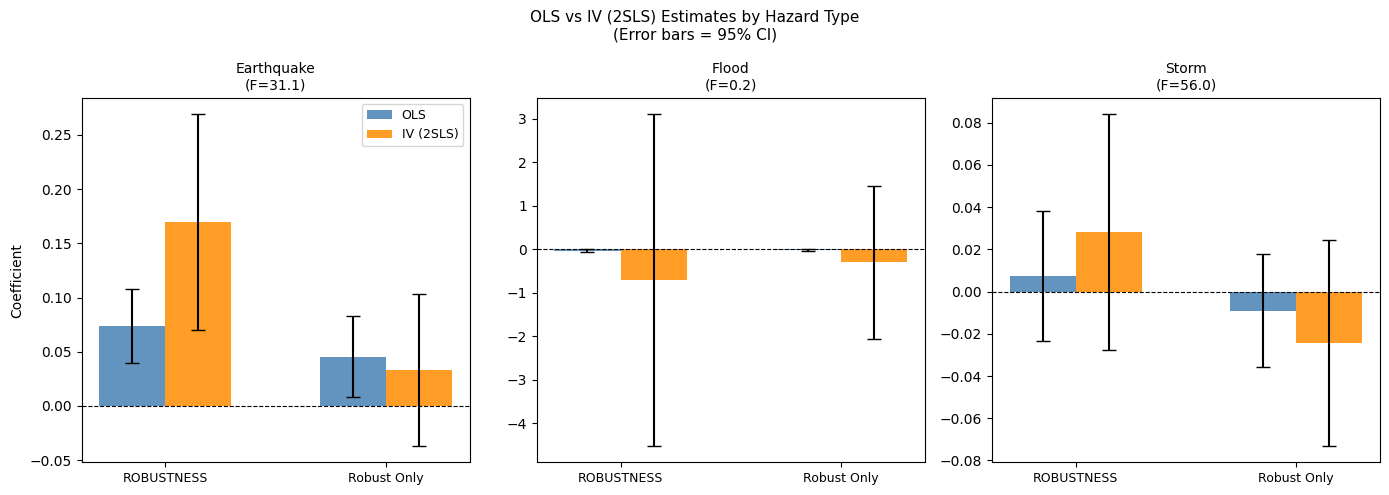

Saved: /content/drive/MyDrive/Resilient_Housing_Global_Regression/Results/IV/OLS_vs_IV_AllHazards.png


In [49]:
# ==============================================================
# CELL 20 — Export comparison data to CSV and plot
# ==============================================================

# CSV
comp_out = os.path.join(OUTPUT_DIR, "OLS_vs_IV_AllHazards.csv")
comp_df.to_csv(comp_out, index=False)
print(f"Saved: {comp_out}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
hazard_list = ['Earthquake', 'Flood', 'Storm']
colors_ols  = 'steelblue'
colors_iv   = 'darkorange'

for ax, hazard in zip(axes, hazard_list):
    sub  = comp_df[comp_df['Hazard'] == hazard].reset_index(drop=True)
    x    = np.arange(len(sub))
    w    = 0.3
    ax.bar(x - w/2, sub['OLS_Coef'], w,
           yerr=sub['OLS_SE']*1.96, capsize=5,
           label='OLS', color=colors_ols, alpha=0.85)
    ax.bar(x + w/2, sub['IV_Coef'],  w,
           yerr=sub['IV_SE']*1.96,  capsize=5,
           label='IV (2SLS)', color=colors_iv,  alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{hazard}\n(F={sub["First_F"].iloc[0]:.1f})', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(['ROBUSTNESS', 'Robust Only'], fontsize=9)
    ax.set_ylabel('Coefficient' if hazard == 'Earthquake' else '')
    if hazard == 'Earthquake':
        ax.legend(fontsize=9)

plt.suptitle('OLS vs IV (2SLS) Estimates by Hazard Type\n(Error bars = 95% CI)',
             fontsize=11)
plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, "OLS_vs_IV_AllHazards.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")
